# **End-to-End Machine Learning Project**

## Defining the Problem

---

To develop an effective machine learning model, it's critical to clearly understand its **use case** and **application context**. In this chapter, we assume the model will serve as an input to another machine learning system, alongside other signals, for predicting house prices.

### Existing Solutions and Limitations

It is equally important to evaluate the current approaches. For house pricing analysis, traditional solutions are typically implemented by statisticians using complex, rule-based methodologies. While effective, these methods often involve high costs and are time-inefficient.

### Understanding the Data Pipeline

A sequence of data processing stages is referred to as a **data pipeline**. These components often operate asynchronously, enhancing system resilience. In case of a failure in one component, its most recent output can be used as a temporary estimate, maintaining system functionality.

### Problem Type and Learning Approach

This scenario is classified as a **regression task**, requiring a **supervised learning algorithm**. Specifically:

- It is a **multivariate regression problem**, as the model will leverage multiple features to predict the target variable: the median house price.
- It is also a **univariate regression task** because only one target variable (house price) is being predicted.
- There is no continuous stream of data in this context; therefore, we are dealing with a static dataset.

### Scalability Considerations

For large datasets, there are two potential approaches to consider:

1. **Batch Learning**: Utilize distributed systems across multiple servers, leveraging frameworks such as the **MapReduce paradigm** for scalability.
2. **Online Learning**: Continuously train the model incrementally as new data becomes available.

By framing the problem with precision and understanding its nuances, we can build a robust foundation for developing the machine learning solution.

## Selecting a Performance Measure

---

For regression problems, a commonly used performance metric is the **Root Mean Square Error (RMSE)**, which is defined as:

> $$RMSE(X, h) = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left(h(x^{(i)}) - y^{(i)}\right)^2}$$

### Parameters Explanation:
- **$(m)$**: Total number of instances in the dataset.
- **$(x^{(i)})$**: Feature vector (excluding labels) of the $(i^\text{th})$ instance.
- **$(y^{(i)})$**: Actual label for the $(i^\text{th})$ instance.
- **$(X)$**: Feature matrix containing all instances, where each row corresponds to a single instance and columns represent features.
- **$(h(x^{(i)}) = \hat{y}^{(i)})$**: Predicted value for the $(i^\text{th})$ instance, computed using the **hypothesis function** $(h)$.
  
The RMSE measures the cost (error) of predictions across the dataset for a given hypothesis \(h\).

### Alternative Metric: Mean Absolute Error (MAE)
While RMSE is widely preferred in regression tasks, it is sensitive to outliers. For datasets with numerous outliers, **Mean Absolute Error (MAE)** can be a robust alternative. It is defined as:

> $$MAE(X, h) = \frac{1}{m} \sum_{i=1}^{m} \left|h(x^{(i)}) - y^{(i)}\right|$$

### Relationship with Norms
- RMSE corresponds to the **Euclidean norm** ($(L_2)$ norm).
- MAE corresponds to the **Manhattan norm** ($(L_1)$ norm).

In general, the $(L_k)$ norm of a vector $(v)$ with $(n)$ elements is defined as:

> $$||v||_k = \left(|v_1|^k + |v_2|^k + \dots + |v_n|^k \right)^{1/k}$$

### Special Cases of Norms:
- **$(L_0)$ norm**: Represents the number of non-zero elements in the vector.
- **$(L_\infty)$ norm**: Represents the maximum absolute value of elements in the vector.

### Choosing Between RMSE and MAE
- **RMSE** is more sensitive to outliers due to squaring of errors, which amplifies large deviations. However, it performs exceptionally well for datasets with a bell-shaped error distribution (Gaussian noise).
- **MAE** provides a more balanced measure when the dataset contains significant outliers, as it penalizes errors linearly.

### Practical Consideration
The choice of a performance measure should align with the characteristics of the dataset and the business problem. For instance:
- Use **RMSE** when capturing large deviations is crucial (e.g., high-precision requirements).
- Use **MAE** when the focus is on robustness against outliers.

## Check Assumptions

---

Assumptions made during data collection are critical to understand, as they directly impact the quality and relevance of the data. Documenting and validating these assumptions ensures that the dataset aligns with the intended use case.

## Acquire the Data

---

1. **Permissions and Authorizations**  
   Verify that you have the necessary permissions to access, use, and utilize the data. This includes ensuring compliance with data privacy regulations and obtaining the required access credentials.

2. **Data Sources and Formats**  
   Typically, data will be provided in a relational database, a common data storage format, or other widely-used sources. These datasets may be distributed across multiple tables, files, or documentations.

3. **Schema Familiarization**  
   Understand the structure of the data by reviewing the schema, which includes:
   - Relationships between tables or entities.
   - Field definitions, such as data types, constraints, and primary keys.
   - Any additional metadata or documentation provided by the data source.

4. **Data Accessibility**  
   Ensure that you have the necessary tools and software to query and process the data efficiently. This may involve setting up access to a database management system (DBMS) or leveraging APIs for retrieving data.

By addressing these steps, you can establish a robust foundation for working with the dataset effectively and securely.


In [46]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

In [47]:
def load_housing_data():
    tarball_path = Path("Data/housing.tgz")
    if not tarball_path.is_file():
        Path("Data").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="Data")
    return pd.read_csv(Path("Data/housing/housing.csv"))

housing = load_housing_data()

## Quick Overview of the Data Structure

To understand the dataset structure, we can perform an initial inspection using the following methods:

### Viewing the Data
- **`head()` Method**: Displays the first 5 rows of the DataFrame, providing a quick glance at the dataset.
- **`info()` Method**: Provides a concise summary of the dataset, including:
  - Total number of rows.
  - Data types of each attribute.
  - Count of non-null values.

### Understanding Data Types
- If a column loaded from a CSV file has a data type of `object`, it is likely textual data.  
  Use the **`value_counts()` method** to identify unique categories and their counts for categorical attributes.

### Summarizing Numerical Attributes
- **`describe()` Method**: Generates a statistical summary of numerical attributes, such as mean, standard deviation, min, max, and quartiles. Null values are ignored.

### Visualizing Distributions
- **`hist()` Method**: Plots histograms for each numerical attribute in the dataset, allowing for a quick visualization of value distributions.

### Observations from the Data
1. **Median Income**:
   - The `median_income` attribute is scaled (not in USD).
   - Values are capped at **15** for higher medians and **0.5** for lower medians, scaled in units of 10,000.

2. **Capped Attributes**:
   - Other attributes, such as `housing_median_age` and `median_house_value`, are also capped.
   - Address these capped values by either:
     - Collecting additional information about the dataset's cap.
     - Excluding these instances from the training data.

3. **Skewed Distributions**:
   - Many histograms are right-skewed, indicating uneven distributions.
   - Features have vastly different scales, which might require scaling or normalization during preprocessing.

This preliminary exploration helps identify potential data issues, such as missing values, outliers, or scaling requirements, and lays the groundwork for more detailed data analysis.


In [48]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [49]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [50]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

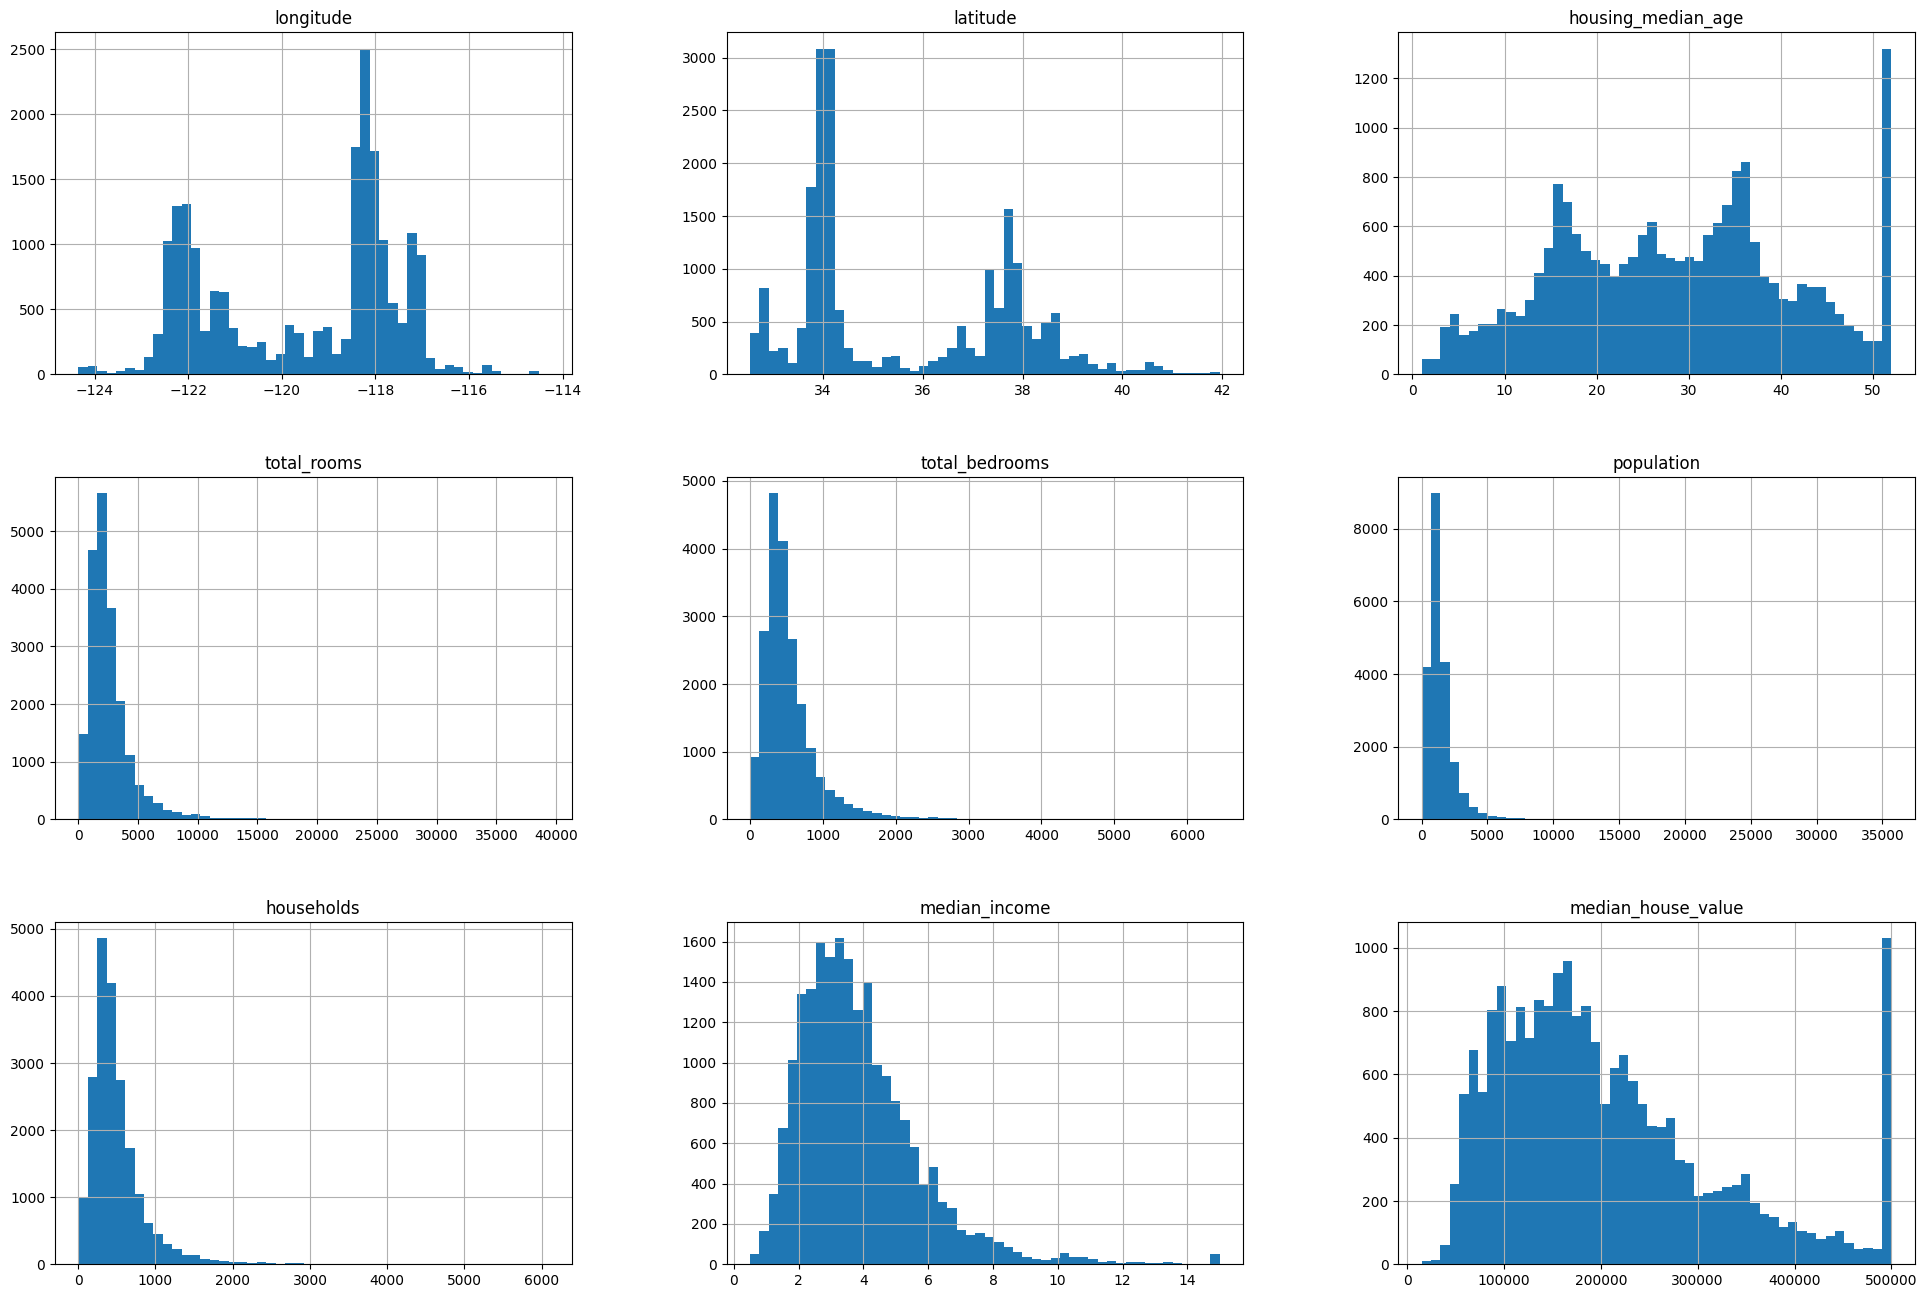

In [51]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(24,16))
plt.show()

## Creating a Test Set

When building machine learning models, our ability to recognize patterns can inadvertently introduce biases during model selection. This can lead to poor generalization on unseen data, a phenomenon known as **data snooping bias**. To mitigate this, it's essential to create a reliable test set.

### Basic Test Set Creation
A simple approach to creating a test set is to randomly set aside **20% of the data** (or a smaller percentage for larger datasets). However, this method has limitations:
1. On re-running the code, the random split generates a different test set, risking eventual exposure of the model to the entire dataset.
2. This can reduce the reliability of test set evaluation.

### Ensuring Consistency in Splits
1. **Save the Test Set Separately**: Manually save the test set to ensure it remains unchanged across runs.
2. **Random Number Generator Seed**:
   - Use a fixed random seed before splitting the dataset. For example:
     ```python
     np.random.seed(42)
     shuffled_indices = np.random.permutation(len(data))
     ```
3. **Index-Based Splitting**:
   - Use each instance's identifier to determine its placement in the train or test set.
   - If no unique identifier exists, create one using the most stable features, assuming:
     - New data is appended to the dataset.
     - No rows are deleted.
   - This method ensures that updates to the dataset don't alter the train-test split.

### Using Scikit-Learn
The **`train_test_split()` function** in Scikit-learn simplifies dataset splitting:
- The `random_state` parameter allows setting a fixed random seed, ensuring reproducible splits.
- Supports splitting multiple datasets with identical row indices.

### Addressing Sampling Bias in Small Datasets
For smaller datasets, random sampling can lead to **sampling bias**. A better approach is **stratified sampling**, which ensures that all important subgroups of the population are proportionally represented.

### Stratified Sampling Example
Suppose the **`median_income`** attribute is critical for predicting housing prices. To ensure it is well-represented:
1. **Transforming Continuous Data**:
   - Use the **`pd.cut()` function** to create an **income category attribute** with predefined bins (e.g., five categories).
     ```python
     data["income_category"] = pd.cut(
         data["median_income"],
         bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
         labels=[1, 2, 3, 4, 5]
     )
     ```
2. **Stratified Sampling**:
   - The `train_test_split()` function includes a **`stratify` argument** for stratified sampling based on an attribute.
   - Example:
     ```python
     train_set, test_set = train_test_split(data, test_size=0.2, stratify=data["income_category"], random_state=42)
     ```

### Validating Sampling Distribution
After stratified sampling, use **`value_counts() \ len()`** to verify the distribution of the categories in both the train and test sets, ensuring they represent the population proportions accurately.

### Advanced Splitting Techniques
Scikit-learn offers additional splitting tools in the **`sklearn.model_selection`** package:
- Splitters (e.g., `StratifiedShuffleSplit`) include a `split()` method that provides train-test splits by indices.
- Multiple splits allow for cross-validation and more robust performance analysis.

By employing these strategies, you can minimize data snooping bias and ensure your test set provides an accurate evaluation of model performance.

In [52]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

train_set, test_set = shuffle_and_split_data(housing, 0.2)
print(len(train_set))
print(len(test_set))

16512
4128


In [53]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio *2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

housing_with_id = housing.reset_index()
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

print(len(train_set))
print(len(test_set))

16512
4128


In [54]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

print(len(train_set))
print(len(test_set))

16322
4318


In [55]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

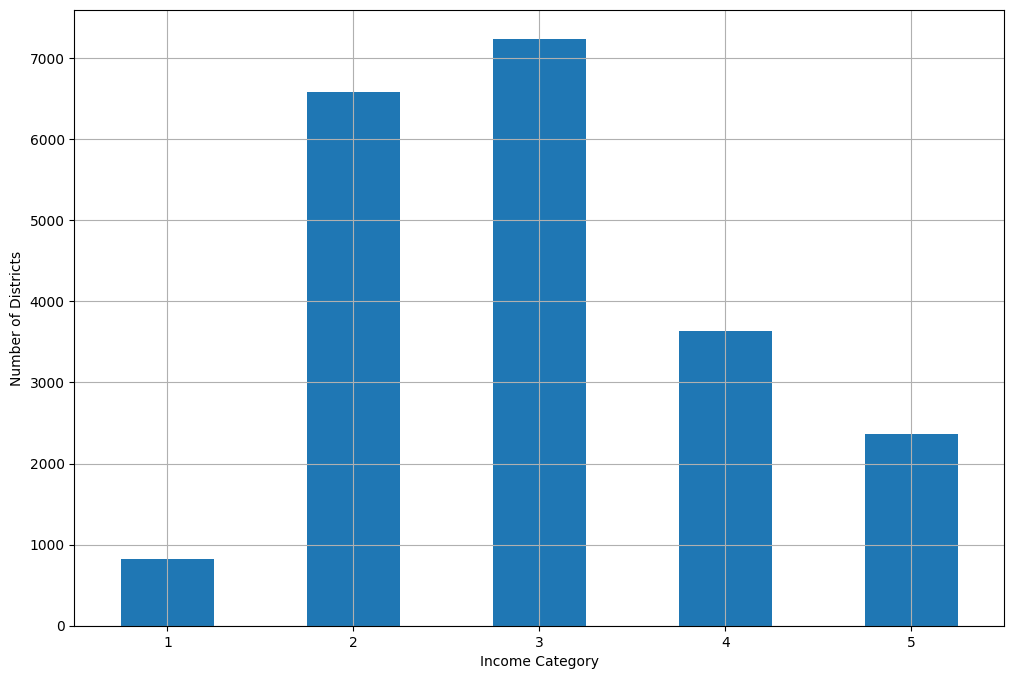

In [56]:
housing["income_cat"] = pd.cut(housing["median_income"], bins=[0.,1.5,3.0,4.5,6.,np.inf],labels=[1,2,3,4,5])

housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True, figsize=(12,8))
plt.xlabel("Income Category")
plt.ylabel("Number of Districts")
plt.show()

In [57]:
from sklearn.model_selection import StratifiedShuffleSplit

# For 10 Splits
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

# Using the first split
strat_train_set, strat_test_set = strat_splits[0]

In [58]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)
strat_test_set["income_cat"].value_counts()/len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [59]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## Explore and Visualize the Data to Gain Insights

After setting aside the test set, we can delve deeper into the training data. To quickly understand the dataset:
- For larger datasets, create a smaller sample to speed up exploration.
- In this case, since the training set is relatively small, we'll use the entire dataset.  
Begin by making a **copy** of the dataset to ensure any modifications can be reverted later.

---

### Visualizing Geographical Data

If the dataset includes **geographical information** (e.g., longitude and latitude), a scatter plot can provide valuable insights:
- Plot the data points using latitude and longitude as axes.
- Set **alpha** to `0.2` for better visualization of high-density regions.
  
To simultaneously visualize a district's **population** and **housing prices**:
- Use a **colormap** to represent housing prices.
- Adjust the **circle size (radius)** based on population size.  
  This approach reveals:
  - Strong location-based trends in housing prices.
  - The influence of population density on prices.

Additionally, applying a **clustering algorithm** can help:
- Detect main clusters in the data.
- Add new features, such as proximity to cluster centers, for better predictive power.

---

### Looking for Correlations

Understanding correlations between attributes is essential:
1. **Pearson’s Correlation Coefficient (r)**:
   - Measures the linear relationship between attributes.
   - Ranges:
     - $(1)$: Strong positive correlation.
     - $(-1)$: Strong negative correlation.
     - $(0)$: No linear correlation.
   - Use:
     ```python
     corr_matrix = data.corr()
     print(corr_matrix["median_house_value"].sort_values(ascending=False))
     ```

2. **Scatter Matrix**:
   - Use `pd.plotting.scatter_matrix()` to visualize relationships between numerical attributes.
   - Focus on key attributes such as:
     - `median_house_value`
     - `median_income`
     - `total_rooms`
     - `housing_median_age`

The scatter matrix’s diagonal is replaced by **histograms** for better representation. Key insights often emerge:
- **Median income** shows the strongest correlation with `median_house_value`.
- The scatter plot may reveal horizontal lines in housing prices caused by artificial capping, which should be addressed by:
  - Removing instances with capped prices to avoid skewing the model's learning.

**Note**: Correlation reflects linear relationships. Other trends may exist, requiring advanced visualization techniques.

---

### Experimenting with Attribute Combinations

Experimentation with new attribute combinations can uncover unexpected patterns:
1. **Examples**:
   - **Bedroom Ratio**:
     - $bedroom\_ratio = \frac{total\_bedrooms}{total\_rooms}$
     - Found to correlate more strongly with `median_house_value` than the absolute `total_bedrooms`.
   - **Population per Household**:
     - $pop\_per\_hold = \frac{population}{households}$

2. **Iterative Approach**:
   - It's not always necessary to experiment with attributes before model development.
   - Start with a prototype model, then revisit feature engineering to optimize results.

By exploring and visualizing the data, you can uncover critical trends and relationships, improving the model's performance and interpretability.

In [60]:
housing = strat_train_set.copy()

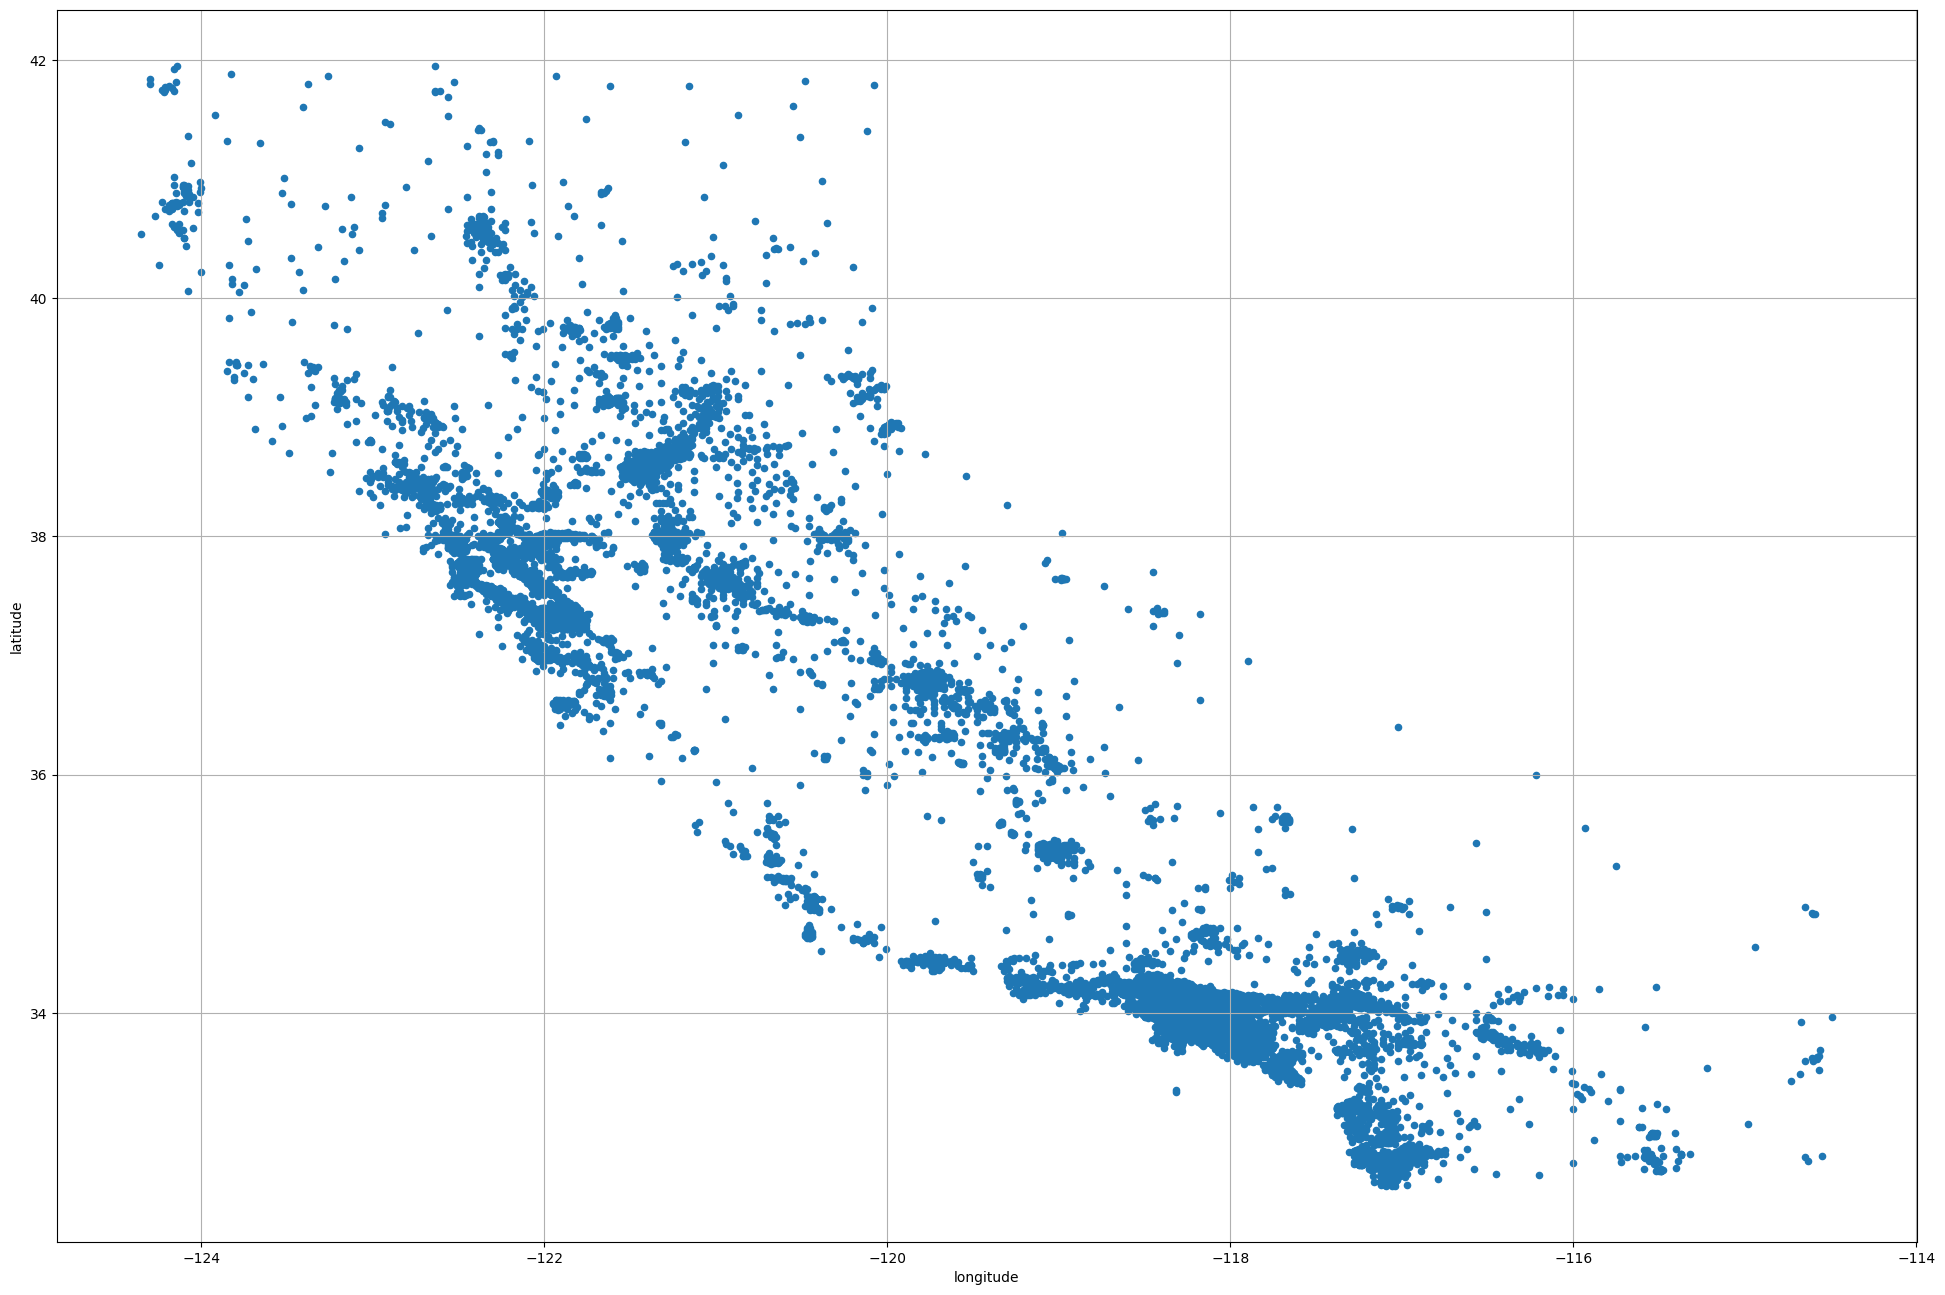

In [61]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    figsize=(24,16)
    )
plt.show()

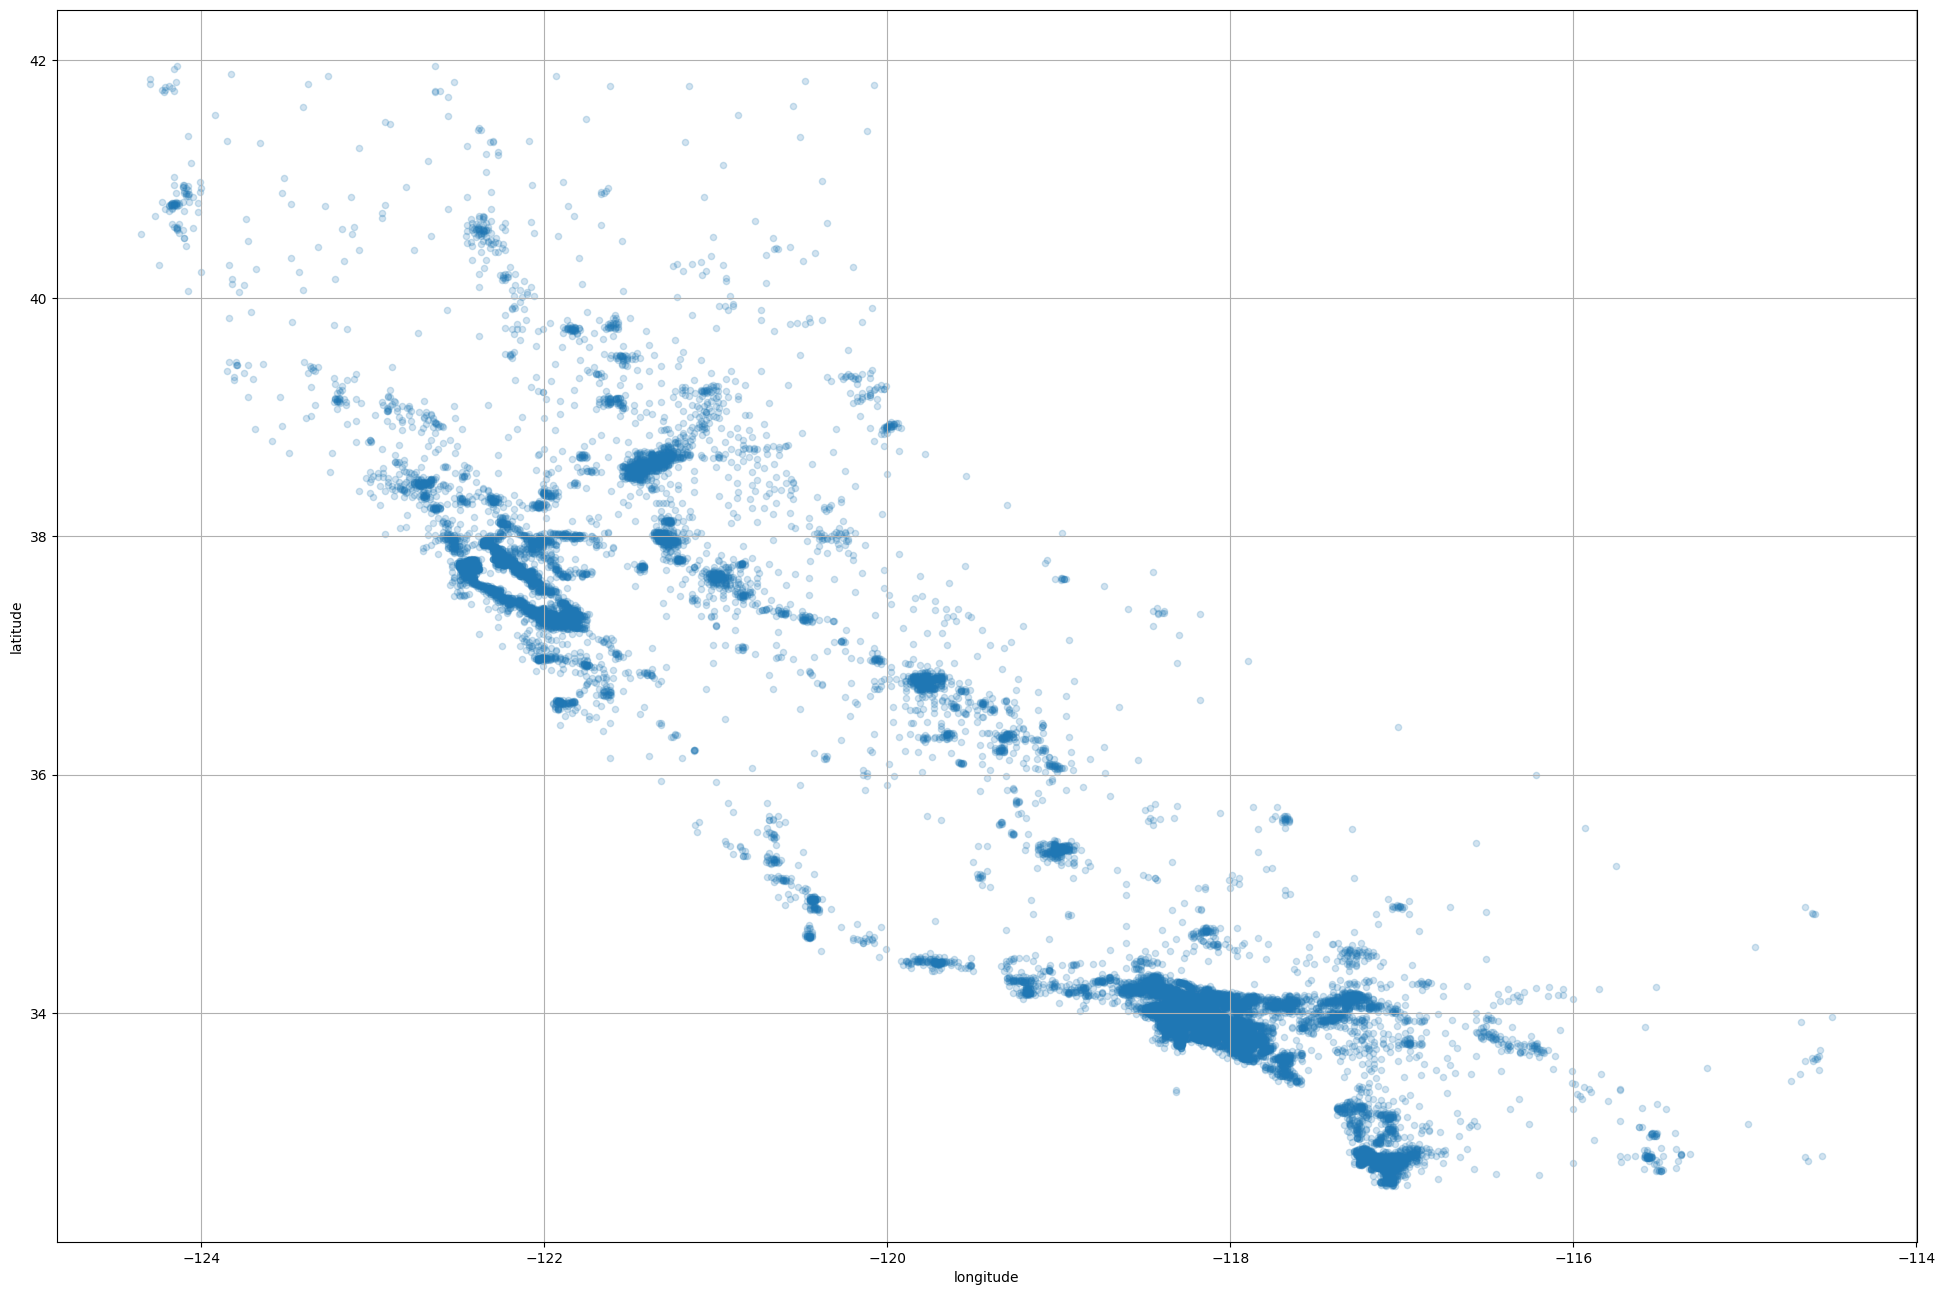

In [62]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    figsize=(24,16),
    alpha=0.2
    )
plt.show()

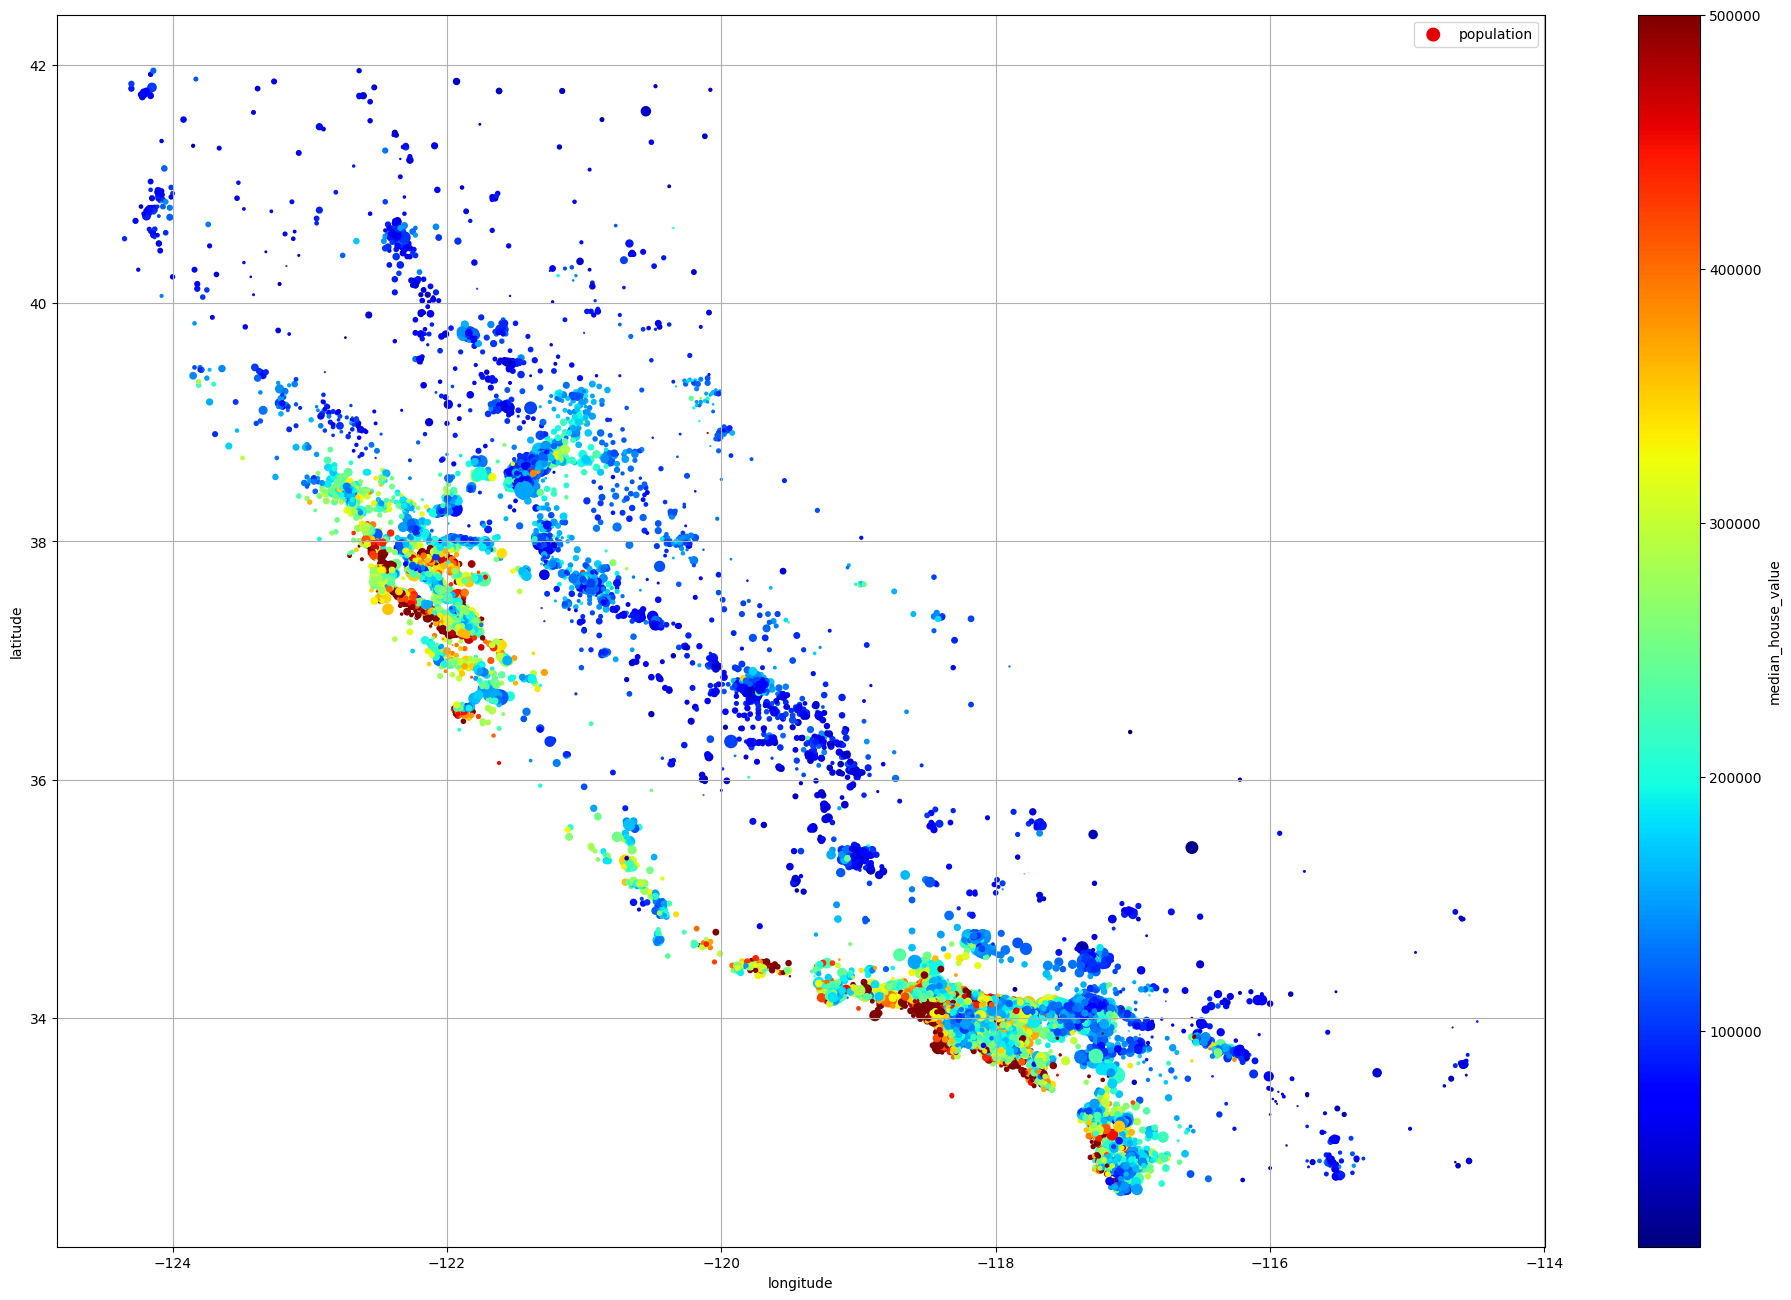

In [63]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    figsize=(24,16),
    s=housing["population"]/100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    legend=True,
    sharex=False
    )
plt.show()

In [64]:
corr_matrix = housing.drop("ocean_proximity", axis=1).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

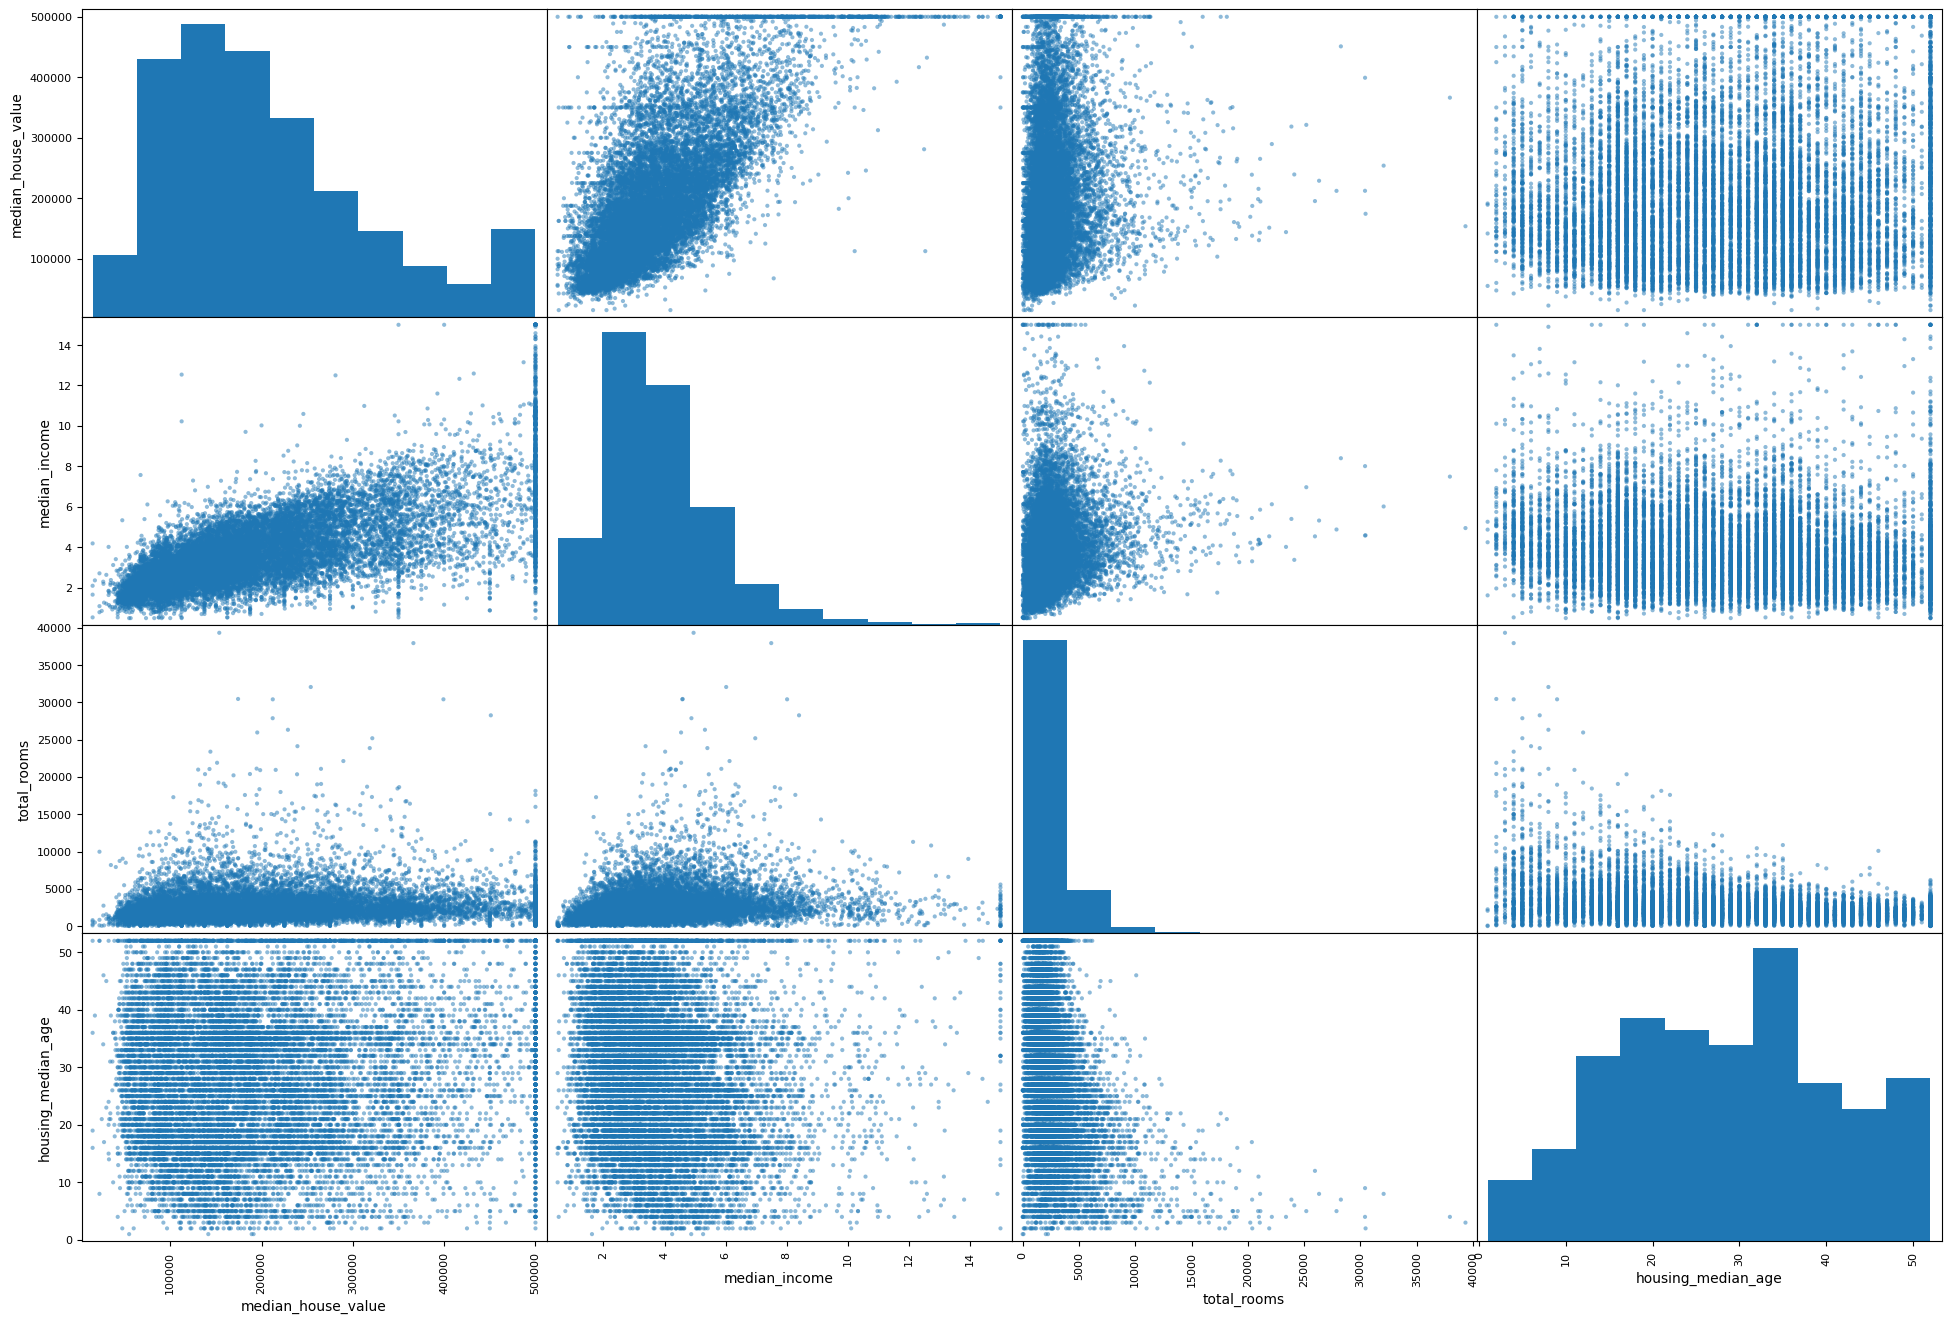

In [65]:
from pandas.plotting import scatter_matrix
attribute = ["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attribute], figsize=(24,16))
plt.show()

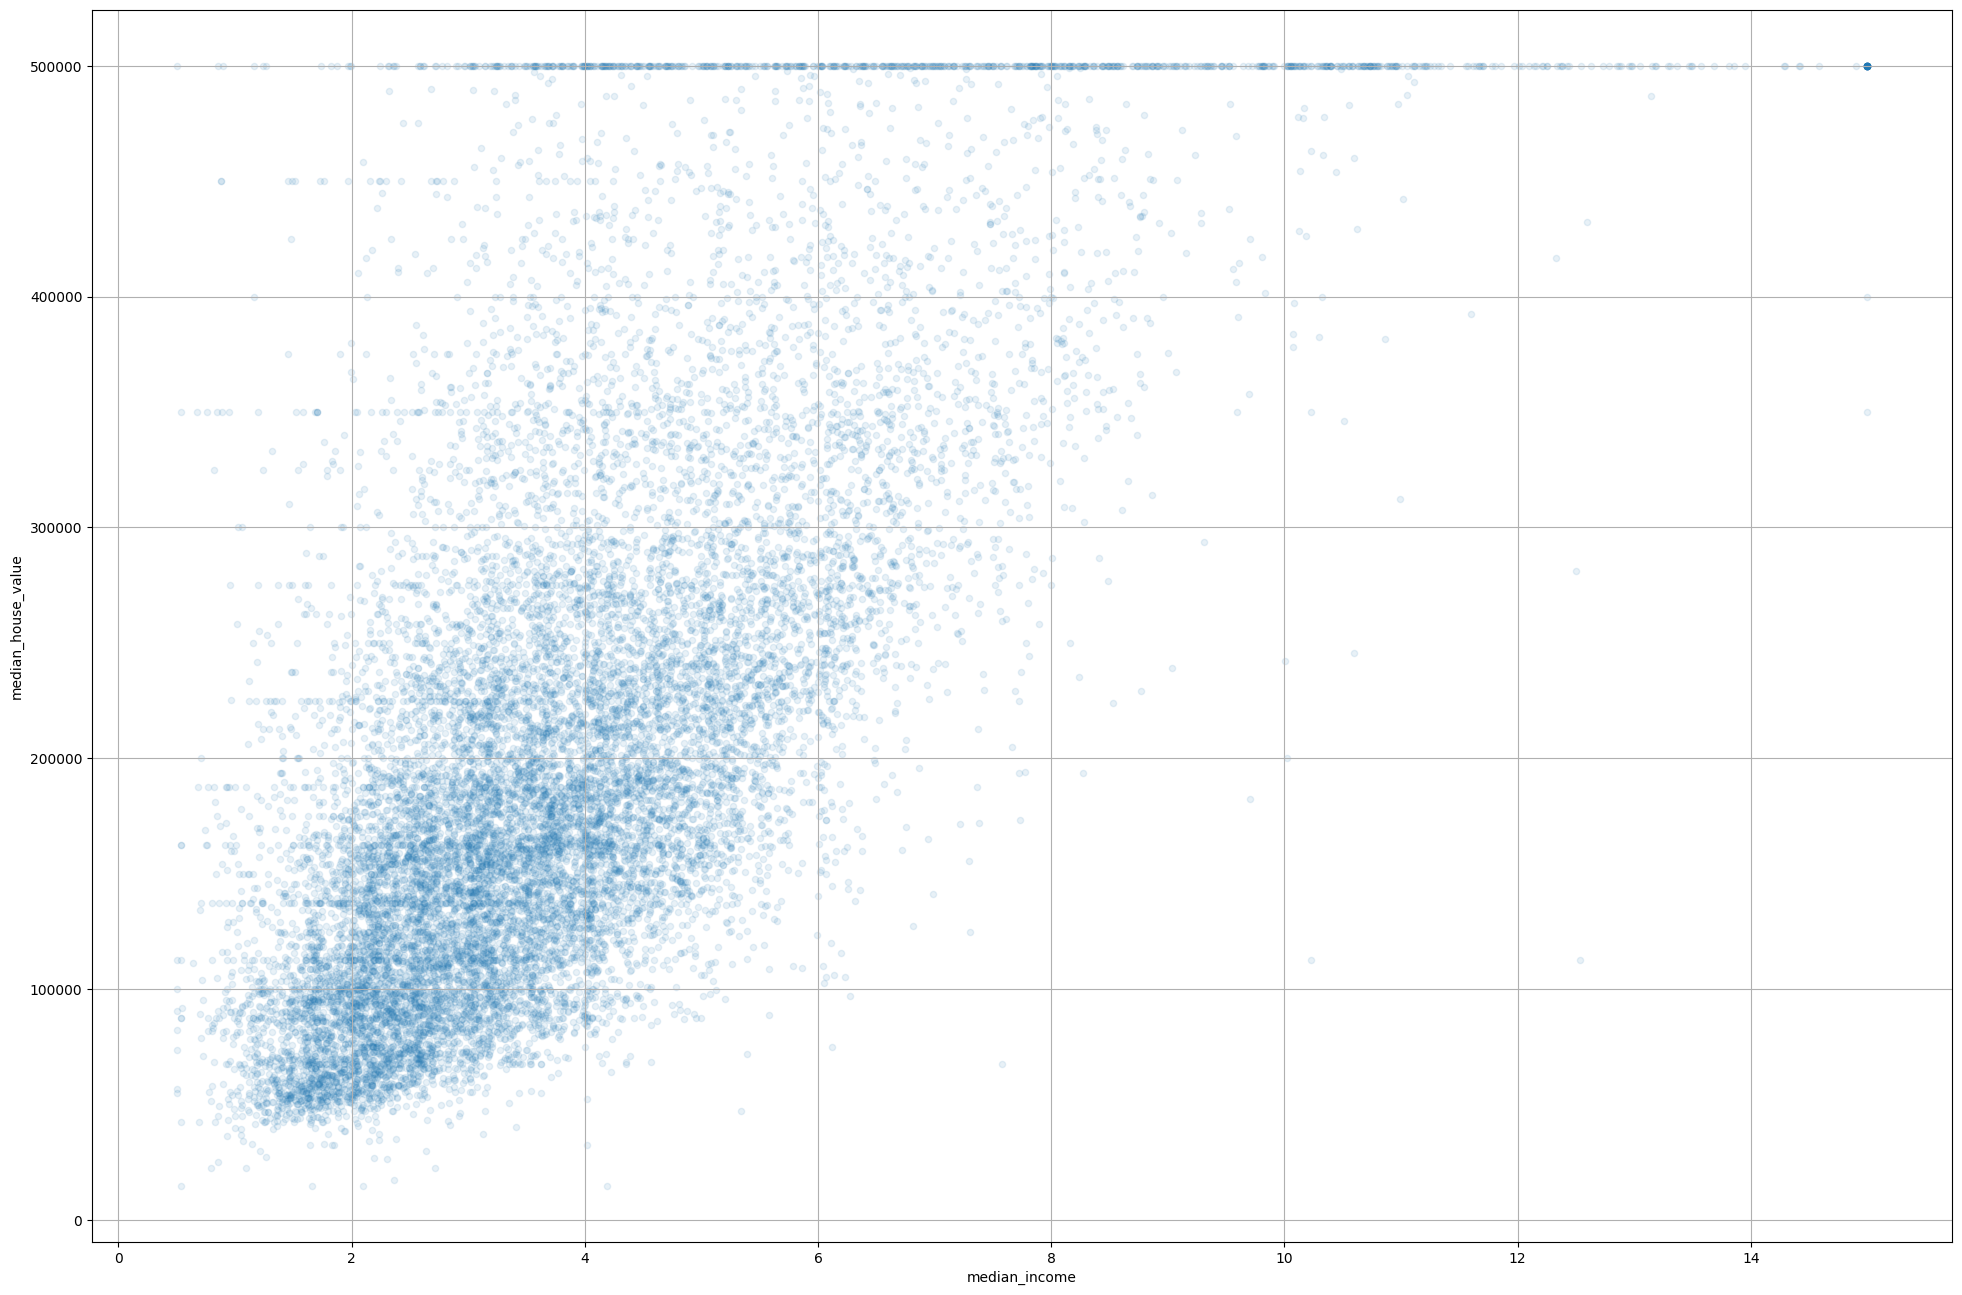

In [66]:
housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1,
    grid=True,
    figsize=(24,16)
    )
plt.show()

In [67]:
housing["rooms_per_house"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["people_per_house"] = housing["population"]/housing["households"]

corr_matrix = housing.drop("ocean_proximity", axis=1).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

## Preparing the Data for Machine Learning Algorithms

To build an efficient machine learning pipeline, it’s essential to prepare the data correctly. We should design reusable functions to transform the data consistently and reliably. Before doing so, we must ensure the data is clean and suitable for analysis.

---

### Cleaning the Data

1. **Separating Predictors and Labels**  
   Start by splitting the dataset into predictors (features) and labels (target variable). This ensures transformations are applied only to the predictors and not the labels.

2. **Handling Missing Data**  
   Most machine learning algorithms cannot handle missing features. Several strategies exist to address this issue:
   - **Remove Rows**: Use `dropna()` to remove rows with missing values.
   - **Remove Attributes**: Use `drop()` to remove columns with many missing values.
   - **Imputation**: Replace missing values with a substitute such as the **mean**, **median**, or **most frequent value** using `fillna()` or Scikit-learn's `SimpleImputer`.

   **Example (Median Imputation):**
   - Select numerical attributes:
     ```python
     from sklearn.impute import SimpleImputer
     imputer = SimpleImputer(strategy="median")
     data_num = data.select_dtypes(include=[np.number])
     imputer.fit(data_num)
     ```
   - Apply imputation to fill missing values:
     ```python
     data_num_imputed = imputer.transform(data_num)
     ```

3. **Advanced Imputation Methods**  
   - **`KNNImputer`**: Replaces missing values with the mean of the k-nearest neighbors.
   - **`IterativeImputer`**: Uses regression models to predict missing values based on other features.

---

### Scikit-Learn Design Principles

- **Estimators**: Objects like `SimpleImputer` that estimate parameters using `fit()`.
  - Example: `imputer.statistics_` stores the learned median values.
- **Transformers**: Estimators that can transform a dataset using `transform()`.
  - Example: `fit_transform()` combines `fit()` and `transform()` in one step.
- **Predictors**: Models like `LinearRegression` that use `predict()` to make predictions and `score()` to evaluate performance.
- **Hyperparameters**: Configuration parameters like `imputer.strategy` that guide the model's behavior.
- **Learned Parameters**: Attributes with an underscore, e.g., `imputer.statistics_`, store learned data from training.

Scikit-learn maintains simplicity by:
- Representing datasets as **NumPy arrays** or **SciPy sparse matrices**.
- Reusing building blocks, such as pipelines to sequence transformations and final predictions.

---

### Handling Text and Categorical Attributes

1. **Identifying Categorical Features**  
   Text features like `Ocean_Proximity` are categorical. Machine learning algorithms require numerical data, so we must convert these categories into numerical formats.

2. **Encoding Categories**
   - **Ordinal Encoding**: Assigns an integer to each category using `OrdinalEncoder`.  
     - Example: `encoder.categories_` lists the categories for each feature.
     - Limitation: Algorithms may incorrectly assume an ordinal relationship between categories.

   - **One-Hot Encoding**: Creates binary attributes (1 if true, 0 otherwise) for each category using `OneHotEncoder`.
     - Example:
       ```python
       from sklearn.preprocessing import OneHotEncoder
       encoder = OneHotEncoder(sparse=False)
       data_encoded = encoder.fit_transform(data[["Ocean_Proximity"]])
       ```
     - Advantages:
       - Avoids ordinal assumptions.
       - Efficiently handles sparse matrices for memory efficiency (`sparse=True` by default).

   - **Handling Unknown Categories**:  
     Use `handle_unknown="ignore"` to safely handle categories not seen during training, representing them as zeros.

3. **Advanced Techniques**  
   - For large numbers of categories:
     - Replace categorical features with **numerical features** derived from them.
     - Use **embedding layers** (low-dimensional learnable vectors) for neural networks.

4. **Pandas Alternative**  
   - Use `pd.get_dummies()` for one-hot encoding:
     - Simpler but less flexible than Scikit-learn’s `OneHotEncoder`.
     - Cannot handle unseen categories gracefully.

#### Final Notes on Transformers

- Scikit-learn transformers output NumPy arrays or SciPy matrices. While this format is efficient, it discards column names. Use:
  - `transformer.get_feature_names_out()` to retrieve transformed feature names.
  - Combine this with pandas to rebuild a DataFrame around the transformer output.

In [68]:
housing = strat_train_set.drop("median_house_value", axis = 1)
housing_labels = strat_train_set["median_house_value"].copy()

In [69]:
# Option 1
housing.dropna(subset=["total_bedrooms"], inplace=True)

# Option 2
housing.drop("total_bedrooms", axis=1)

# Option 3
medains = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(medains, inplace=True)

/var/folders/0s/bt69j7tj0pd5rl5dzr4n6bth0000gn/T/ipykernel_4215/792563658.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(medains, inplace=True)


In [70]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [71]:
print(imputer.statistics_)
print(housing_num.median().values)

[-118.51     34.26     29.     2125.5     434.     1167.      408.5
    3.5409]
[-118.51     34.26     29.     2125.5     434.     1167.      408.5
    3.5409]


In [72]:
X = imputer.transform(housing_num)

In [73]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [74]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [75]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [76]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [77]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [78]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16344 stored elements and shape (16344, 5)>

In [79]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16344, 5))

In [80]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [81]:
df_test = pd.DataFrame({"ocean_proximity":["ISLAND","NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [82]:
cat_encoder.transform(df_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (2, 5)>

In [83]:
df_test_unknown = pd.DataFrame({"ocean_proximity":["<2H OCEAN","ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


In [84]:
cat_encoder.handle_unknown="ignore"
df_test_unknown_encoded = cat_encoder.transform(df_test_unknown)

In [85]:
df_test_unknown_encoded.toarray()

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [86]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [87]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [88]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown).toarray(),columns=cat_encoder.get_feature_names_out(),index=df_test_unknown.index)

## Feature Scaling and Transformation

Feature scaling is a critical preprocessing step in machine learning. Most algorithms require numerical features to be on the same scale for optimal performance. With a few exceptions, scaling ensures that features contribute equally to the model. Below are common scaling and transformation techniques:

---

### Types of Feature Scaling

1. **Min-Max Scaling (Normalization)**  
   - Each attribute is shifted and scaled to fit within a specified range, typically **[0, 1]**.
   - Formula:
     $$
     X' = \frac{X - X_\text{min}}{X_\text{max} - X_\text{min}}
     $$
   - Implementation:
     ```python
     from sklearn.preprocessing import MinMaxScaler
     scaler = MinMaxScaler(feature_range=(0, 1))
     data_scaled = scaler.fit_transform(data)
     ```
   - Notes:
     - The `feature_range` hyperparameter allows customization (e.g., **[-1, 1]** for neural networks requiring 0 mean).
     - Sensitive to outliers, as extreme values can disproportionately affect scaling.

2. **Standardization**  
   - Each attribute's mean is subtracted, and the result is divided by its standard deviation.
   - Formula:
     $$
     X' = \frac{X - \mu}{\sigma}
     $$
   - Implementation:
     ```python
     from sklearn.preprocessing import StandardScaler
     scaler = StandardScaler()
     data_scaled = scaler.fit_transform(data)
     ```
   - Notes:
     - Unlike Min-Max Scaling, it does not restrict values to a fixed range.
     - Less sensitive to outliers.
     - For sparse matrices, set `with_mean=False` to avoid dense conversion.

---

### Dealing with Heavy Tails and Skewed Distributions

For features with **heavy tails** (many extreme values far from the mean), scaling alone is insufficient. Consider the following steps before scaling:

1. **Symmetric Transformations**  
   - Apply transformations like **square root** or **logarithm** to compress extreme values and make the distribution more symmetrical.

2. **Bucketing**  
   - Divide the distribution into **equal-sized buckets** and replace feature values with the bucket indices.
   - Often used in stratified sampling.

3. **Multimodal Distributions**  
   - For features with multiple peaks (modes), **bucketize** the feature and treat bucket indices as categories.
   - Use **OneHotEncoder** to encode these categories.

---

### Adding Similarity Features

For multimodal distributions, it may be beneficial to create **similarity-based features**:
1. **Radial Basis Function (RBF)**:
   - Calculate the similarity of a feature value to specific modes (e.g., housing median age compared to a particular mode).
   - Gaussian RBF is commonly used:
     $$
     \text{RBF}(x, \mu) = \exp\left(-\gamma (x - \mu)^2\right)
     $$
     - **\(\gamma\)** (gamma): Controls the rate of similarity decay.
   - Implementation:
     ```python
     from sklearn.metrics.pairwise import rbf_kernel
     similarity = rbf_kernel(data, centers, gamma=0.1)
     ```

   - **Use Case**:
     - Add RBF-based similarity features to represent proximity to specific modes.
     - Enhance the model's ability to capture non-linear relationships.

---

### Practical Notes

1. **Fit on Training Data Only**  
   Always fit scaling or transformation techniques to the **training data** and apply the same transformation to validation/test data. This avoids data leakage.
   - Example:
     ```python
     scaler.fit(train_data)
     train_data_scaled = scaler.transform(train_data)
     test_data_scaled = scaler.transform(test_data)
     ```

2. **Sparse Data Scaling**  
   For sparse matrices:
   - Use `StandardScaler` with `with_mean=False` to avoid subtracting the mean.
   - Ensure scaling methods maintain matrix sparsity for memory efficiency.

3. **Combining Techniques**  
   Use a **pipeline** to sequence transformations and ensure consistency:
   ```python
   from sklearn.pipeline import Pipeline
   pipeline = Pipeline([
       ('scaler', StandardScaler()),
       ('model', SomeMLModel())
   ])
   pipeline.fit(X_train, y_train)

By implementing these feature scaling and transformation techniques, you can significantly improve model performance and its ability to learn from the data effectively.

---

In [89]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1,1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [90]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)